# PyTorch Workflow Fundamentals — Using `nn.Linear`

**Objective:** Rebuild the same linear regression problem from Notebook 1,
but this time using PyTorch's built-in `nn.Linear` layer instead of
manually creating parameters, and add device-agnostic code so the same
model can run on CPU or GPU.

In [ ]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

## Preparing and Loading Data

Same synthetic dataset as Notebook 1 (`y = weight * X + bias`), so the
two notebooks are directly comparable.

In [ ]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight*X+bias

In [ ]:
print(f"The length of X is {len(X)}")
print(f"The length of y is {len(y)}")

The length of X is 50
The length of y is 50


## Splitting Data into Training and Test Sets

Same 80/20 split as Notebook 1.

In [ ]:
train_split = int(0.8*len(X))

X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train) ,len(y_train) , len(X_test) , len(y_test)

(40, 40, 10, 10)

## Setting Up Device-Agnostic Code

Checking for a GPU (`cuda`) means this same code works whether it's run
locally on CPU or on a GPU — a standard habit in real PyTorch code.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"The device is {device}")

The device is cpu


## Visualizing the Data

In [ ]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None) :

  plt.figure(figsize=(10,6))

  plt.scatter(train_data,train_labels,c="b",s=4,label="Training Data")

  plt.scatter(test_data,test_labels,c="g",s=4,label="Testing Data")

  if predictions is not None:
    plt.scatter(test_data,predictions,c="r",s=4,label="Predictions")

  plt.legend(prop={"size":14});

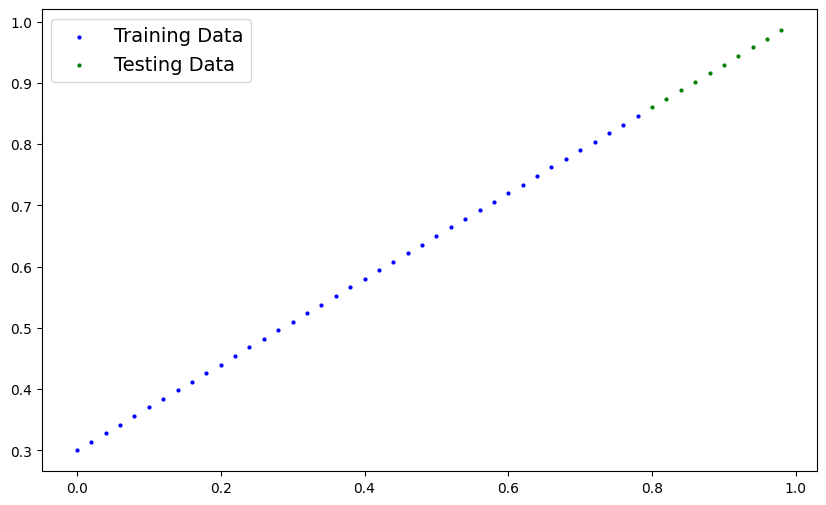

In [ ]:
plot_predictions();

## Building the Model (Using `nn.Linear`)

This time, instead of manually creating weight and bias as `nn.Parameter`,
we use `nn.Linear(in_features=1, out_features=1)`, which does the same
thing internally but is the standard way models are built in practice.

In [ ]:
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()

    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)

  def forward(self,x:torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

torch.manual_seed(42)
model_1 = LinearRegressionModelV2()

model_1 , model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [ ]:
list(model_1.parameters())

[Parameter containing:
 tensor([[0.7645]], requires_grad=True),
 Parameter containing:
 tensor([0.8300], requires_grad=True)]

In [ ]:
next(model_1.parameters()).device

device(type='cpu')

## Loss Function and Optimizer

Same setup as Notebook 1 — `L1Loss` and `SGD` — so the only difference
between the two notebooks is how the model itself is defined.

In [ ]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr=0.01)

## Training the Model

In [ ]:
torch.manual_seed(42)

epochs = 200

for epoch in range(epochs):

  model_1.train()

  y_pred = model_1(X_train)

  loss = loss_fn(y_pred,y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()


  model_1.eval()
  with torch.inference_mode():

    test_pred = model_1(X_test)

    test_loss = loss_fn(test_pred,y_test)


  if epoch%10==0 :

    print(f"Epoch : {epoch} | Loss : {loss} | Test Loss : {test_loss}")


Epoch : 0 | Loss : 0.5551779866218567 | Test Loss : 0.5739762187004089
Epoch : 10 | Loss : 0.4399680495262146 | Test Loss : 0.4392663538455963
Epoch : 20 | Loss : 0.3247582018375397 | Test Loss : 0.30455657839775085
Epoch : 30 | Loss : 0.20954827964305878 | Test Loss : 0.16984674334526062
Epoch : 40 | Loss : 0.09433844685554504 | Test Loss : 0.03513689711689949
Epoch : 50 | Loss : 0.023886386305093765 | Test Loss : 0.04784906655550003
Epoch : 60 | Loss : 0.0199567973613739 | Test Loss : 0.04580312222242355
Epoch : 70 | Loss : 0.016517987474799156 | Test Loss : 0.0375305712223053
Epoch : 80 | Loss : 0.013089170679450035 | Test Loss : 0.029944902285933495
Epoch : 90 | Loss : 0.009653178043663502 | Test Loss : 0.02167237363755703
Epoch : 100 | Loss : 0.006215679459273815 | Test Loss : 0.014086711220443249
Epoch : 110 | Loss : 0.002787243574857712 | Test Loss : 0.005814164876937866
Epoch : 120 | Loss : 0.0012645035749301314 | Test Loss : 0.013801807537674904
Epoch : 130 | Loss : 0.00126450

In [ ]:
list(model_1.parameters())

[Parameter containing:
 tensor([[0.6968]], requires_grad=True),
 Parameter containing:
 tensor([0.3025], requires_grad=True)]

## Visualizing Predictions After Training

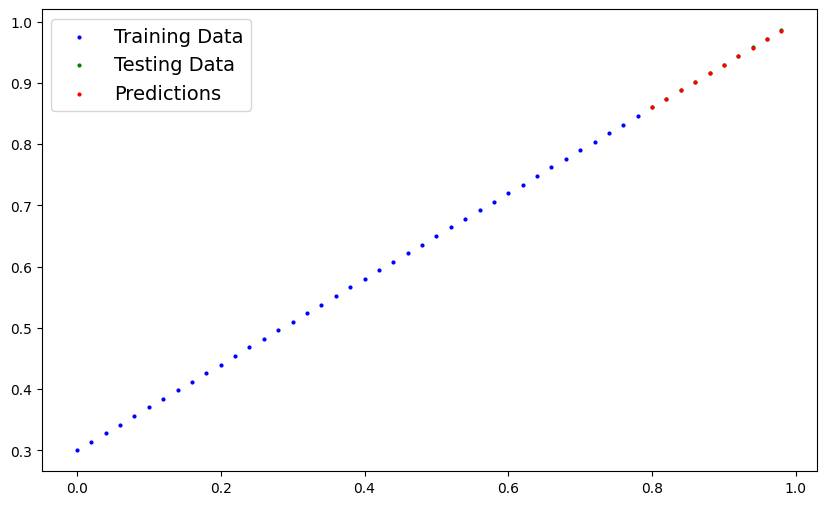

In [ ]:
plot_predictions(predictions=test_pred)

## Saving the Model

In [ ]:
from pathlib import Path

MODEL_PATH = Path("model")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

MODEL_NAME = "pytorch_,model_01.pth"

MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH

print(f"Saving model to : {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to : model/pytorch_,model_01.pth


## Loading the Model

In [ ]:
loaded_model_1 = LinearRegressionModelV2()

loaded_model_1.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

In [ ]:
loaded_model_1.eval()

with torch.inference_mode():
  loaded_model_preds=loaded_model_1(X_test)

loaded_model_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

In [ ]:
test_pred == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## Key Learnings

- `nn.Linear` replaces manually created `nn.Parameter` weights and bias —
  same math, less code, fewer chances for mistakes.
- Writing `device = "cuda" if torch.cuda.is_available() else "cpu"` up
  front is the standard pattern for making code run anywhere.
- Comparing this notebook to Notebook 1: the workflow (data → model →
  train → save/load) never changes — only how the model itself is
  defined.